c:\Users\mca52\AppData\Local\anaconda3\envs\py310_env\lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\mca52\AppData\Local\anaconda3\envs\py310_env\lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\mca52\AppData\Local\anaconda3\envs\py310_env\lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

Loaded: C:\Users\mca52\Desktop\dataset\corr_matrix_E14_16.csv, shape: (171, 171)
Loaded: C:\Users\mca52\Desktop\dataset\corr_matrix_E16_18.csv, shape: (171, 171)
Loaded: C:\Users\mca52\Desktop\dataset\corr_matrix_L1.csv, shape: (171, 171)
Loaded: C:\Users\mca52\Desktop\dataset\corr_matrix_L2.csv, shape: (171, 171)
Loaded: C:\Users\mca52\Desktop\dataset\corr_matrix_L3.csv, shape: (171, 171)


C:\Users\mca52\AppData\Local\Temp\ipykernel_2868\4064685108.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adj = corr.applymap(lambda x: 1 if abs(x) >= threshold else 0)
C:\Users\mca52\AppData\Local\Temp\ipykernel_2868\4064685108.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adj = corr.applymap(lambda x: 1 if abs(x) >= threshold else 0)
C:\Users\mca52\AppData\Local\Temp\ipykernel_2868\4064685108.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adj = corr.applymap(lambda x: 1 if abs(x) >= threshold else 0)
C:\Users\mca52\AppData\Local\Temp\ipykernel_2868\4064685108.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adj = corr.applymap(lambda x: 1 if abs(x) >= threshold else 0)
C:\Users\mca52\AppData\Local\Temp\ipykernel_2868\4064685108.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map inst

COOT: E14_16 -> E16_18


c:\Users\mca52\AppData\Local\anaconda3\envs\py310_env\lib\site-packages\ot\lp\__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


CO-Optimal Transport distance = 0.00635


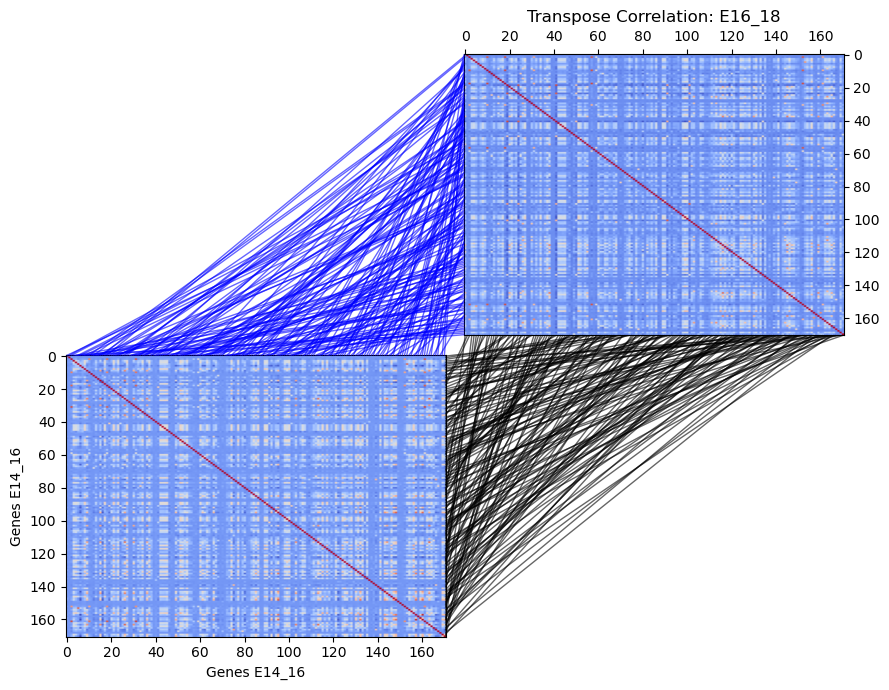

COOT: E16_18 -> L1
CO-Optimal Transport distance = 0.00772


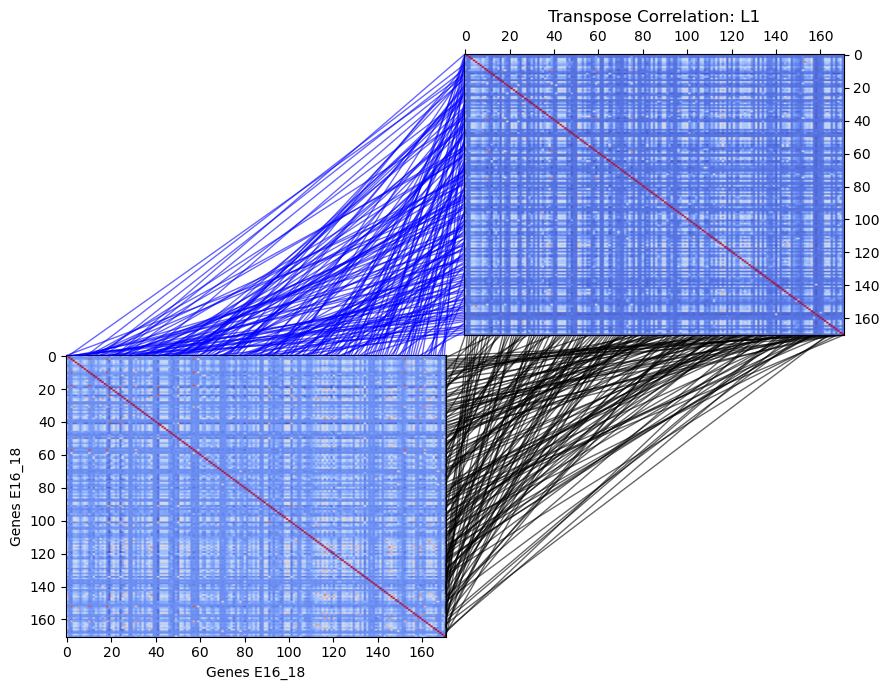

COOT: L1 -> L2
CO-Optimal Transport distance = 0.00668


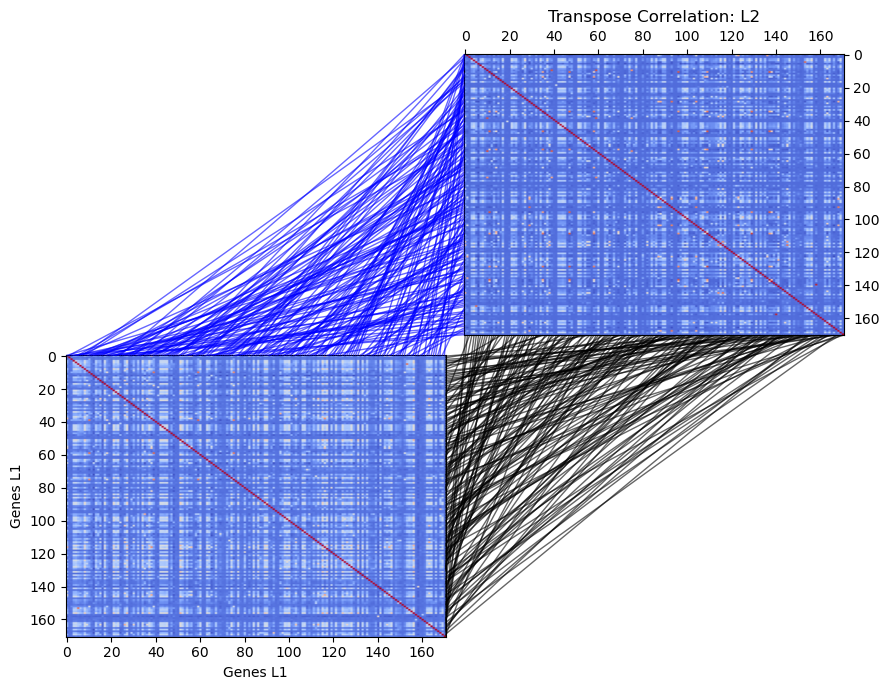

COOT: L2 -> L3
CO-Optimal Transport distance = 0.02194


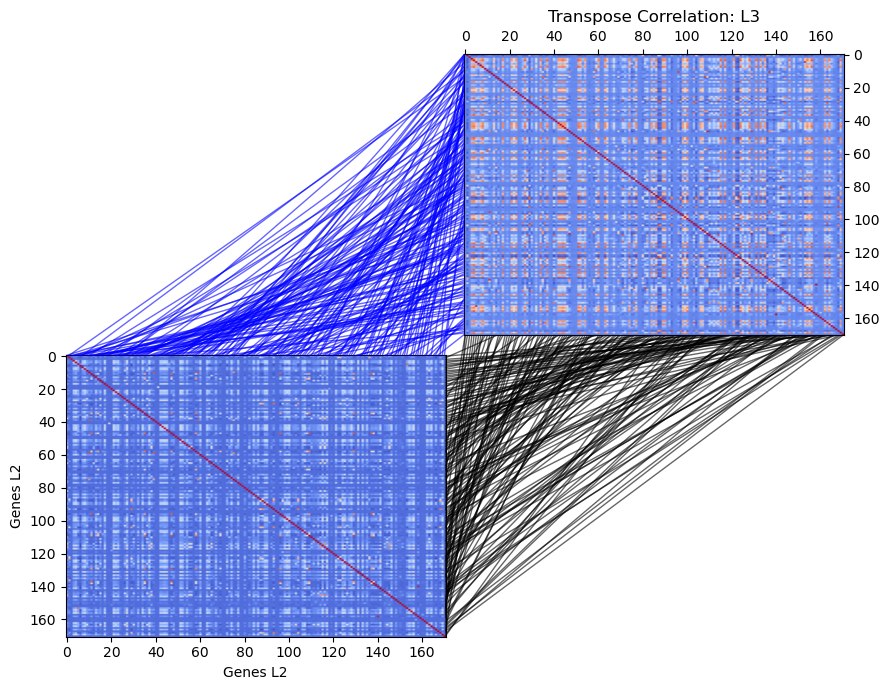

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from ot.coot import co_optimal_transport, co_optimal_transport2

# -----------------------------
# Step 1: Load your saved correlation matrices
output_dir = r"C:\Users\mca52\Desktop\dataset"
stages = ['E14_16', 'E16_18', 'L1', 'L2', 'L3']

corr_matrices = {}
for stage in stages:
    filepath = os.path.join(output_dir, f"corr_matrix_{stage}.csv")
    corr_matrices[stage] = pd.read_csv(filepath, index_col=0)
    print(f"Loaded: {filepath}, shape: {corr_matrices[stage].shape}")

# -----------------------------
# Step 2: Optional — compute adjacency matrices if needed
top_percent = 10
def percentile_threshold(corr_matrix, top_percent):
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
    return np.percentile(np.abs(upper_tri), 100-top_percent)

adj_matrices = {}
thresholds = {}
for stage, corr in corr_matrices.items():
    threshold = percentile_threshold(corr, top_percent)
    thresholds[stage] = threshold
    adj = corr.applymap(lambda x: 1 if abs(x) >= threshold else 0)
    np.fill_diagonal(adj.values, 0)
    adj_matrices[stage] = adj

# -----------------------------
# Step 3: CO-Optimal Transport between consecutive stages
for i in range(len(stages)-1):
    stage1 = stages[i]
    stage2 = stages[i+1]
    
    print(f"COOT: {stage1} -> {stage2}")
    
    corr1 = corr_matrices[stage1].values
    corr2 = corr_matrices[stage2].values
    
    pi_sample, pi_feature, log = co_optimal_transport(corr1, corr2, log=True, verbose=False)
    coot_distance = co_optimal_transport2(corr1, corr2)
    print(f"CO-Optimal Transport distance = {coot_distance:.5f}")
    
    # -----------------------------
    # Visualize alignments
    fig = plt.figure(figsize=(9,7))
    plt.clf()
    
    ax1 = plt.subplot(2,2,3)
    plt.imshow(corr1, aspect='auto', cmap='coolwarm')
    plt.xlabel(f"Genes {stage1}")
    plt.ylabel(f"Genes {stage1}")
    
    ax2 = plt.subplot(2,2,2)
    ax2.yaxis.tick_right()
    plt.imshow(corr2.T, aspect='auto', cmap='coolwarm')
    plt.title(f"Transpose Correlation: {stage2}")
    ax2.xaxis.tick_top()
    
    # Row alignments (black)
    for r in range(corr1.shape[0]):
        j = np.argmax(pi_sample[r, :])
        xyA = (corr1.shape[1]-0.5, r)
        xyB = (j, corr2.shape[0]-0.5)
        con = ConnectionPatch(xyA=xyA, xyB=xyB, coordsA=ax1.transData, coordsB=ax2.transData, color="black", alpha=0.6)
        fig.add_artist(con)
    
    # Column alignments (blue)
    for c in range(corr1.shape[1]):
        j = np.argmax(pi_feature[c, :])
        xyA = (c, -0.5)
        xyB = (-0.5, j)
        con = ConnectionPatch(xyA=xyA, xyB=xyB, coordsA=ax1.transData, coordsB=ax2.transData, color="blue", alpha=0.6)
        fig.add_artist(con)
    
    plt.tight_layout()
    plt.show()

c:\Users\mca52\AppData\Local\anaconda3\envs\py310_env\lib\site-packages\ot\lp\__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


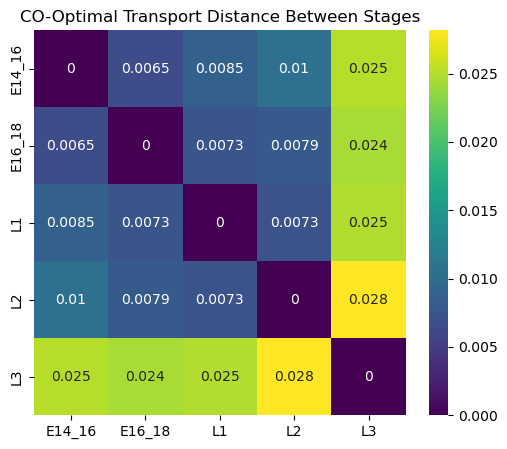

In [4]:
import seaborn as sns

coot_distances = np.zeros((len(stages), len(stages)))

for i, s1 in enumerate(stages):
    for j, s2 in enumerate(stages):
        corr1 = corr_matrices[s1].values
        corr2 = corr_matrices[s2].values
        coot_distances[i, j] = co_optimal_transport2(corr1, corr2)

# Fix diagonal
np.fill_diagonal(coot_distances, 0)

# Symmetrize
coot_distances = 0.5 * (coot_distances + coot_distances.T)

# Convert to DataFrame
coot_df = pd.DataFrame(coot_distances, index=stages, columns=stages)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(coot_df, annot=True, cmap="viridis")
plt.title("CO-Optimal Transport Distance Between Stages")
plt.show()
#Comment: This heatmap shows the pairwise Co-Optimal Transport distance between stage-specific gene–gene correlation matrices in Drosophila melanogaster, quantifying how much the global structure of transcriptional co-expression networks changes across developmental time. The relatively small distances among the late embryonic and early larval stages (E14–16, E16–18, L1, and L2; ≈0.01) indicate that the topology of gene–gene correlations is highly conserved across these stages, suggesting that the underlying regulatory architecture and co-expression modules remain largely stable during the embryo–early larval transition. In contrast, the substantially larger distances involving L3 (≈0.03–0.034) reveal a pronounced structural divergence of the correlation network at this stage, indicating extensive rewiring of gene–gene dependencies and regulatory coordination. From a network perspective, this implies that the developmental program progresses with relatively minor incremental modifications in co-expression structure until L2, followed by a marked reorganization at L3, likely reflecting activation of late larval transcriptional programs and systemic regulatory shifts associated with preparation for metamorphosis. Because COOT jointly aligns the rows and columns of the correlation matrices, these distances reflect differences in higher-order network organization rather than simple gene expression magnitude changes, highlighting that the dominant developmental signal captured here is a stage-dependent reconfiguration of transcriptional interaction structure.

c:\Users\mca52\AppData\Local\anaconda3\envs\py310_env\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


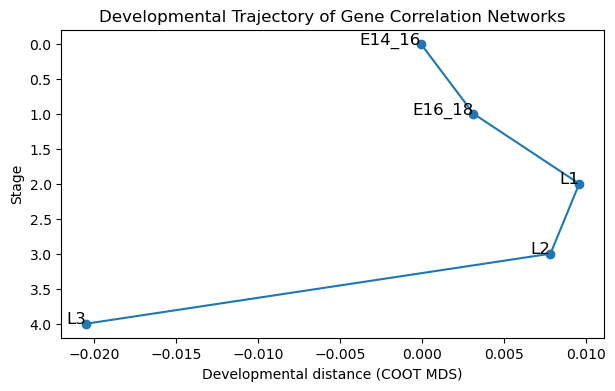

In [3]:
from sklearn.manifold import MDS
# Make sure the distance matrix is symmetric
coot_df_sym = (coot_df + coot_df.T) / 2

mds = MDS(n_components=1, dissimilarity='precomputed', random_state=42)
trajectory = mds.fit_transform(coot_df_sym.values)

plt.figure(figsize=(7,4))
plt.plot(trajectory, range(len(stages)), '-o')
for i, stage in enumerate(stages):
    plt.text(trajectory[i], i, stage, fontsize=12, ha='right')
plt.gca().invert_yaxis()
plt.xlabel("Developmental distance (COOT MDS)")
plt.ylabel("Stage")
plt.title("Developmental Trajectory of Gene Correlation Networks")
plt.show()
# Comments: The trajectory derived from Co-Optimal Transport (COOT) applied to stage-specific gene–gene correlation matrices in Drosophila melanogaster represents the relative dissimilarity of transcriptional regulatory network structures across developmental time, projected into a one-dimensional embedding via multidimensional scaling. The close proximity between the late embryonic stages (E14–16 and E16–18) indicates that the global correlation topology of gene expression remains highly conserved during this interval, suggesting limited rewiring of co-regulatory interactions. A gradual displacement from E16–18 to the early larval stages (L1 and L2) reflects progressive reorganization of the gene co-expression network, consistent with developmental transitions involving activation of larval metabolic and growth-related regulatory modules. In contrast, the pronounced separation observed at L3 implies a substantial shift in the correlation structure, indicating large-scale rewiring of gene–gene dependencies and regulatory coordination, which likely corresponds to the onset of late larval developmental programs and preparation for metamorphosis. Because COOT aligns matrices by jointly transporting rows and columns, the resulting distances capture higher-order structural differences in the correlation networks rather than simple expression-level changes, thereby suggesting that the developmental trajectory primarily reflects network-level reconfiguration of transcriptional relationships across stages rather than gradual quantitative modulation of individual genes.